# Лабораторная работа №5.2

**Студент:** Тавуз Мохамад  
**Группа:** ИУ5И-22М  

**Тема:** Реализация алгоритма Policy Iteration

In [1]:
# Импорт необходимых библиотек для выполнения лабораторной работы

try:
    import gym
except ImportError:
    !pip install gym==0.26.2
    import gym

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tqdm import tqdm
from pprint import pprint

# Исправление совместимости Gym с NumPy 2.0
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_

print("Библиотеки успешно импортированы")
print("Версия Gym:", gym.__version__)
print("Версия NumPy:", np.__version__)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Библиотеки успешно импортированы
Версия Gym: 0.25.2
Версия NumPy: 2.0.2


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
# Создание среды Taxi-v3 и вывод основных характеристик среды

env = gym.make("Taxi-v3")

print("Среда:", "Taxi-v3")
print("Пространство состояний:")
pprint(env.observation_space)

print("\nПространство действий:")
pprint(env.action_space)

print("\nДиапазон наград:")
pprint(env.reward_range)

print("\nКоличество состояний:", env.observation_space.n)
print("Количество действий:", env.action_space.n)

state = env.reset()
if isinstance(state, tuple):
    state = state[0]

print("\nНачальное состояние:", state)

Среда: Taxi-v3
Пространство состояний:
Discrete(500)

Пространство действий:
Discrete(6)

Диапазон наград:
(-inf, inf)

Количество состояний: 500
Количество действий: 6

Начальное состояние: 408


/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [3]:
# Создание базового класса агента для алгоритмов временных различий

class BasicAgent:
    '''
    Базовый класс агента для алгоритмов SARSA, Q-Learning и Double Q-Learning.
    '''
    ALGO_NAME = "---"

    def __init__(self, env, eps=0.4, lr=0.1, gamma=0.98,
                 num_episodes=5000, max_steps=200):
        self.env = env

        # Размерности пространства состояний и действий
        self.nS = env.observation_space.n
        self.nA = env.action_space.n

        # Q-таблица
        self.Q = np.zeros((self.nS, self.nA))

        # Параметры обучения
        self.eps = eps
        self.initial_eps = eps
        self.lr = lr
        self.gamma = gamma
        self.num_episodes = num_episodes
        self.max_steps = max_steps

        # Постепенное уменьшение eps
        self.eps_decay = eps / num_episodes
        self.eps_threshold = 0.01

        # История обучения
        self.episodes_reward = []
        self.episodes_steps = []


    def get_state(self, state):
        '''
        Получение номера состояния с учетом разных версий Gym.
        '''
        if isinstance(state, tuple):
            return state[0]
        return state


    def greedy(self, state):
        '''
        Выбор действия с максимальным Q-значением.
        '''
        return np.argmax(self.Q[state])


    def make_action(self, state):
        '''
        Выбор действия по epsilon-greedy стратегии.
        '''
        if np.random.uniform(0, 1) < self.eps:
            return self.env.action_space.sample()
        return self.greedy(state)


    def update_epsilon(self):
        '''
        Постепенное уменьшение вероятности случайного действия.
        '''
        if self.eps > self.eps_threshold:
            self.eps -= self.eps_decay


    def print_info(self):
        '''
        Вывод основной информации об агенте.
        '''
        print("Алгоритм:", self.ALGO_NAME)
        print("Количество состояний:", self.nS)
        print("Количество действий:", self.nA)
        print("Learning rate:", self.lr)
        print("Gamma:", self.gamma)
        print("Начальное epsilon:", self.initial_eps)
        print("Количество эпизодов:", self.num_episodes)
        print("Максимальное количество шагов:", self.max_steps)
        print("Размер Q-таблицы:", self.Q.shape)


basic_agent = BasicAgent(env)
basic_agent.print_info()

Алгоритм: ---
Количество состояний: 500
Количество действий: 6
Learning rate: 0.1
Gamma: 0.98
Начальное epsilon: 0.4
Количество эпизодов: 5000
Максимальное количество шагов: 200
Размер Q-таблицы: (500, 6)


In [4]:
# Реализация алгоритма SARSA

class SARSA_Agent(BasicAgent):
    '''
    Агент, реализующий алгоритм SARSA.
    '''
    ALGO_NAME = "SARSA"

    def learn(self):
        '''
        Обучение агента на основе алгоритма SARSA.
        '''
        self.episodes_reward = []
        self.episodes_steps = []
        self.eps = self.initial_eps

        start_time = time.time()

        for episode in tqdm(range(self.num_episodes)):
            state = self.get_state(self.env.reset())
            action = self.make_action(state)

            total_reward = 0
            steps = 0
            done = False
            truncated = False

            self.update_epsilon()

            while not (done or truncated) and steps < self.max_steps:
                step_result = self.env.step(action)

                if len(step_result) == 5:
                    next_state, reward, done, truncated, info = step_result
                else:
                    next_state, reward, done, info = step_result
                    truncated = False

                next_action = self.make_action(next_state)

                self.Q[state][action] = self.Q[state][action] + self.lr * (
                    reward + self.gamma * self.Q[next_state][next_action] - self.Q[state][action]
                )

                state = next_state
                action = next_action
                total_reward += reward
                steps += 1

            self.episodes_reward.append(total_reward)
            self.episodes_steps.append(steps)

        self.training_time = time.time() - start_time
        print("Обучение SARSA завершено")
        print("Время обучения:", self.training_time)
        print("Последнее значение epsilon:", self.eps)
        print("Средняя награда за последние 100 эпизодов:", np.mean(self.episodes_reward[-100:]))
        print("Среднее количество шагов за последние 100 эпизодов:", np.mean(self.episodes_steps[-100:]))


sarsa_agent = SARSA_Agent(env)
sarsa_agent.print_info()
sarsa_agent.learn()

Алгоритм: SARSA
Количество состояний: 500
Количество действий: 6
Learning rate: 0.1
Gamma: 0.98
Начальное epsilon: 0.4
Количество эпизодов: 5000
Максимальное количество шагов: 200
Размер Q-таблицы: (500, 6)


100%|██████████| 5000/5000 [00:07<00:00, 693.80it/s] 

Обучение SARSA завершено
Время обучения: 7.214331388473511
Последнее значение epsilon: 0.009999999999962976
Средняя награда за последние 100 эпизодов: 7.33
Среднее количество шагов за последние 100 эпизодов: 13.49


In [5]:
# Реализация алгоритма Q-Learning

class QLearning_Agent(BasicAgent):
    '''
    Агент, реализующий алгоритм Q-Learning.
    '''
    ALGO_NAME = "Q-Learning"

    def learn(self):
        '''
        Обучение агента на основе алгоритма Q-Learning.
        '''
        self.episodes_reward = []
        self.episodes_steps = []
        self.eps = self.initial_eps

        start_time = time.time()

        for episode in tqdm(range(self.num_episodes)):
            state = self.get_state(self.env.reset())

            total_reward = 0
            steps = 0
            done = False
            truncated = False

            self.update_epsilon()

            while not (done or truncated) and steps < self.max_steps:
                action = self.make_action(state)

                step_result = self.env.step(action)

                if len(step_result) == 5:
                    next_state, reward, done, truncated, info = step_result
                else:
                    next_state, reward, done, info = step_result
                    truncated = False

                self.Q[state][action] = self.Q[state][action] + self.lr * (
                    reward + self.gamma * np.max(self.Q[next_state]) - self.Q[state][action]
                )

                state = next_state
                total_reward += reward
                steps += 1

            self.episodes_reward.append(total_reward)
            self.episodes_steps.append(steps)

        self.training_time = time.time() - start_time
        print("Обучение Q-Learning завершено")
        print("Время обучения:", self.training_time)
        print("Последнее значение epsilon:", self.eps)
        print("Средняя награда за последние 100 эпизодов:", np.mean(self.episodes_reward[-100:]))
        print("Среднее количество шагов за последние 100 эпизодов:", np.mean(self.episodes_steps[-100:]))


qlearning_agent = QLearning_Agent(env)
qlearning_agent.print_info()
qlearning_agent.learn()

Алгоритм: Q-Learning
Количество состояний: 500
Количество действий: 6
Learning rate: 0.1
Gamma: 0.98
Начальное epsilon: 0.4
Количество эпизодов: 5000
Максимальное количество шагов: 200
Размер Q-таблицы: (500, 6)


100%|██████████| 5000/5000 [00:07<00:00, 706.47it/s] 

Обучение Q-Learning завершено
Время обучения: 7.0818822383880615
Последнее значение epsilon: 0.009999999999962976
Средняя награда за последние 100 эпизодов: 7.28
Среднее количество шагов за последние 100 эпизодов: 13.18


In [6]:
# Реализация алгоритма Double Q-Learning

class DoubleQLearning_Agent(BasicAgent):
    '''
    Агент, реализующий алгоритм Double Q-Learning.
    '''
    ALGO_NAME = "Double Q-Learning"

    def __init__(self, env, eps=0.4, lr=0.1, gamma=0.98,
                 num_episodes=5000, max_steps=200):
        super().__init__(env, eps, lr, gamma, num_episodes, max_steps)

        # В Double Q-Learning используются две Q-таблицы
        self.Q1 = np.zeros((self.nS, self.nA))
        self.Q2 = np.zeros((self.nS, self.nA))


    def greedy(self, state):
        '''
        Выбор действия по сумме двух Q-таблиц.
        '''
        return np.argmax(self.Q1[state] + self.Q2[state])


    def make_action(self, state):
        '''
        Выбор действия по epsilon-greedy стратегии.
        '''
        if np.random.uniform(0, 1) < self.eps:
            return self.env.action_space.sample()
        return self.greedy(state)


    def learn(self):
        '''
        Обучение агента на основе алгоритма Double Q-Learning.
        '''
        self.episodes_reward = []
        self.episodes_steps = []
        self.eps = self.initial_eps

        start_time = time.time()

        for episode in tqdm(range(self.num_episodes)):
            state = self.get_state(self.env.reset())

            total_reward = 0
            steps = 0
            done = False
            truncated = False

            self.update_epsilon()

            while not (done or truncated) and steps < self.max_steps:
                action = self.make_action(state)

                step_result = self.env.step(action)

                if len(step_result) == 5:
                    next_state, reward, done, truncated, info = step_result
                else:
                    next_state, reward, done, info = step_result
                    truncated = False

                if np.random.rand() < 0.5:
                    best_next_action = np.argmax(self.Q1[next_state])
                    self.Q1[state][action] = self.Q1[state][action] + self.lr * (
                        reward + self.gamma * self.Q2[next_state][best_next_action] - self.Q1[state][action]
                    )
                else:
                    best_next_action = np.argmax(self.Q2[next_state])
                    self.Q2[state][action] = self.Q2[state][action] + self.lr * (
                        reward + self.gamma * self.Q1[next_state][best_next_action] - self.Q2[state][action]
                    )

                state = next_state
                total_reward += reward
                steps += 1

            self.episodes_reward.append(total_reward)
            self.episodes_steps.append(steps)

        # Итоговая Q-таблица используется для проверки агента
        self.Q = self.Q1 + self.Q2
        self.training_time = time.time() - start_time

        print("Обучение Double Q-Learning завершено")
        print("Время обучения:", self.training_time)
        print("Последнее значение epsilon:", self.eps)
        print("Средняя награда за последние 100 эпизодов:", np.mean(self.episodes_reward[-100:]))
        print("Среднее количество шагов за последние 100 эпизодов:", np.mean(self.episodes_steps[-100:]))
        print("Размер Q1-таблицы:", self.Q1.shape)
        print("Размер Q2-таблицы:", self.Q2.shape)


double_q_agent = DoubleQLearning_Agent(env)
double_q_agent.print_info()
double_q_agent.learn()

Алгоритм: Double Q-Learning
Количество состояний: 500
Количество действий: 6
Learning rate: 0.1
Gamma: 0.98
Начальное epsilon: 0.4
Количество эпизодов: 5000
Максимальное количество шагов: 200
Размер Q-таблицы: (500, 6)


100%|██████████| 5000/5000 [00:08<00:00, 557.01it/s] 

Обучение Double Q-Learning завершено
Время обучения: 8.981478452682495
Последнее значение epsilon: 0.009999999999962976
Средняя награда за последние 100 эпизодов: 7.87
Среднее количество шагов за последние 100 эпизодов: 12.86
Размер Q1-таблицы: (500, 6)
Размер Q2-таблицы: (500, 6)


In [7]:
# Проверка обученных агентов после завершения обучения

def evaluate_agent(env, agent, episodes_count=20, max_steps=200):
    '''
    Проверка качества обученного агента на нескольких тестовых эпизодах.
    '''
    rewards = []
    steps_list = []
    successful_episodes = 0

    for episode in range(episodes_count):
        state = agent.get_state(env.reset())

        total_reward = 0
        steps = 0
        done = False
        truncated = False

        while not (done or truncated) and steps < max_steps:
            action = agent.greedy(state)
            step_result = env.step(action)

            if len(step_result) == 5:
                next_state, reward, done, truncated, info = step_result
            else:
                next_state, reward, done, info = step_result
                truncated = False

            total_reward += reward
            state = next_state
            steps += 1

        if total_reward > 0:
            successful_episodes += 1

        rewards.append(total_reward)
        steps_list.append(steps)

    return rewards, steps_list, successful_episodes


sarsa_test_rewards, sarsa_test_steps, sarsa_successful = evaluate_agent(env, sarsa_agent)
qlearning_test_rewards, qlearning_test_steps, qlearning_successful = evaluate_agent(env, qlearning_agent)
double_q_test_rewards, double_q_test_steps, double_q_successful = evaluate_agent(env, double_q_agent)

print("Проверка обученных агентов завершена")

print("\nSARSA:")
print("Количество успешных эпизодов:", sarsa_successful)
print("Средняя награда:", np.mean(sarsa_test_rewards))
print("Среднее количество шагов:", np.mean(sarsa_test_steps))

print("\nQ-Learning:")
print("Количество успешных эпизодов:", qlearning_successful)
print("Средняя награда:", np.mean(qlearning_test_rewards))
print("Среднее количество шагов:", np.mean(qlearning_test_steps))

print("\nDouble Q-Learning:")
print("Количество успешных эпизодов:", double_q_successful)
print("Средняя награда:", np.mean(double_q_test_rewards))
print("Среднее количество шагов:", np.mean(double_q_test_steps))

Проверка обученных агентов завершена

SARSA:
Количество успешных эпизодов: 20
Средняя награда: 7.35
Среднее количество шагов: 13.65

Q-Learning:
Количество успешных эпизодов: 20
Средняя награда: 8.15
Среднее количество шагов: 12.85

Double Q-Learning:
Количество успешных эпизодов: 20
Средняя награда: 7.4
Среднее количество шагов: 13.6


In [8]:
# Формирование сравнительной таблицы результатов алгоритмов

comparison_table = pd.DataFrame({
    "Алгоритм": [
        "SARSA",
        "Q-Learning",
        "Double Q-Learning"
    ],
    "Время обучения": [
        sarsa_agent.training_time,
        qlearning_agent.training_time,
        double_q_agent.training_time
    ],
    "Средняя награда при обучении": [
        np.mean(sarsa_agent.episodes_reward[-100:]),
        np.mean(qlearning_agent.episodes_reward[-100:]),
        np.mean(double_q_agent.episodes_reward[-100:])
    ],
    "Среднее число шагов при обучении": [
        np.mean(sarsa_agent.episodes_steps[-100:]),
        np.mean(qlearning_agent.episodes_steps[-100:]),
        np.mean(double_q_agent.episodes_steps[-100:])
    ],
    "Успешных тестовых эпизодов": [
        sarsa_successful,
        qlearning_successful,
        double_q_successful
    ],
    "Средняя тестовая награда": [
        np.mean(sarsa_test_rewards),
        np.mean(qlearning_test_rewards),
        np.mean(double_q_test_rewards)
    ],
    "Среднее число шагов при тестировании": [
        np.mean(sarsa_test_steps),
        np.mean(qlearning_test_steps),
        np.mean(double_q_test_steps)
    ]
})

comparison_table

,Алгоритм,Время обучения,Средняя награда при обучении,Среднее число шагов при обучении,Успешных тестовых эпизодов,Средняя тестовая награда,Среднее число шагов при тестировании
0,SARSA,7.214331,7.33,13.49,20,7.35,13.65
1,Q-Learning,7.081882,7.28,13.18,20,8.15,12.85
2,Double Q-Learning,8.981478,7.87,12.86,20,7.40,13.60


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


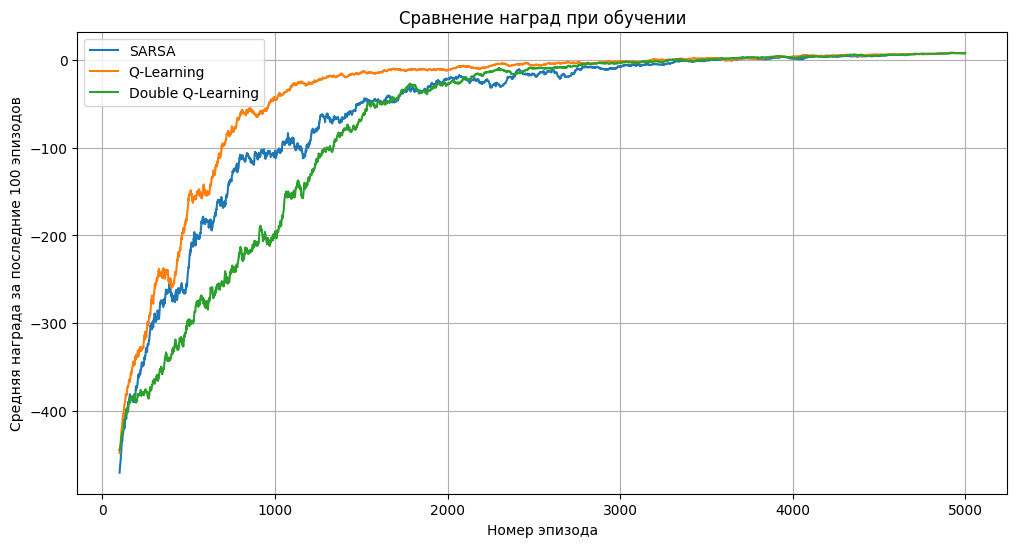

In [9]:
# Построение графика сравнения наград при обучении

window = 100

sarsa_smoothed_rewards = pd.Series(sarsa_agent.episodes_reward).rolling(window).mean()
qlearning_smoothed_rewards = pd.Series(qlearning_agent.episodes_reward).rolling(window).mean()
double_q_smoothed_rewards = pd.Series(double_q_agent.episodes_reward).rolling(window).mean()

plt.figure(figsize=(12, 6))

plt.plot(sarsa_smoothed_rewards, label="SARSA")
plt.plot(qlearning_smoothed_rewards, label="Q-Learning")
plt.plot(double_q_smoothed_rewards, label="Double Q-Learning")

plt.title("Сравнение наград при обучении")
plt.xlabel("Номер эпизода")
plt.ylabel("Средняя награда за последние 100 эпизодов")
plt.legend()
plt.grid(True)
plt.show()

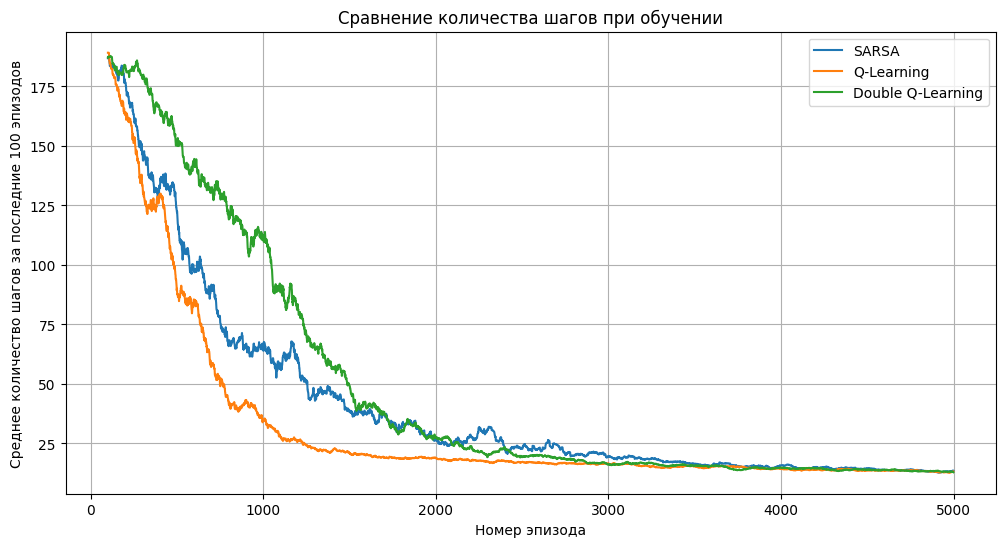

In [10]:
# Построение графика сравнения количества шагов при обучении

window = 100

sarsa_smoothed_steps = pd.Series(sarsa_agent.episodes_steps).rolling(window).mean()
qlearning_smoothed_steps = pd.Series(qlearning_agent.episodes_steps).rolling(window).mean()
double_q_smoothed_steps = pd.Series(double_q_agent.episodes_steps).rolling(window).mean()

plt.figure(figsize=(12, 6))

plt.plot(sarsa_smoothed_steps, label="SARSA")
plt.plot(qlearning_smoothed_steps, label="Q-Learning")
plt.plot(double_q_smoothed_steps, label="Double Q-Learning")

plt.title("Сравнение количества шагов при обучении")
plt.xlabel("Номер эпизода")
plt.ylabel("Среднее количество шагов за последние 100 эпизодов")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# Формирование итоговой таблицы лабораторной работы

final_summary = pd.DataFrame({
    "Показатель": [
        "Среда",
        "Количество состояний",
        "Количество действий",
        "Количество эпизодов обучения",
        "Максимальное количество шагов",
        "Лучший алгоритм по средней тестовой награде",
        "Лучшая средняя тестовая награда",
        "Минимальное среднее число шагов при тестировании",
        "Количество успешных тестовых эпизодов для каждого алгоритма"
    ],
    "Значение": [
        "Taxi-v3",
        env.observation_space.n,
        env.action_space.n,
        sarsa_agent.num_episodes,
        sarsa_agent.max_steps,
        comparison_table.loc[comparison_table["Средняя тестовая награда"].idxmax(), "Алгоритм"],
        comparison_table["Средняя тестовая награда"].max(),
        comparison_table["Среднее число шагов при тестировании"].min(),
        "20 из 20"
    ]
})

final_summary

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Показатель,Значение
0,Среда,Taxi-v3
1,Количество состояний,500
2,Количество действий,6
3,Количество эпизодов обучения,5000
4,Максимальное количество шагов,200
5,Лучший алгоритм по средней тестовой награде,Q-Learning
6,Лучшая средняя тестовая награда,8.15
7,Минимальное среднее число шагов при тестировании,12.85
8,Количество успешных тестовых эпизодов для кажд...,20 из 20


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
# Повторный вывод сравнительной таблицы для фиксации итоговых результатов

comparison_table

,Алгоритм,Время обучения,Средняя награда при обучении,Среднее число шагов при обучении,Успешных тестовых эпизодов,Средняя тестовая награда,Среднее число шагов при тестировании
0,SARSA,7.214331,7.33,13.49,20,7.35,13.65
1,Q-Learning,7.081882,7.28,13.18,20,8.15,12.85
2,Double Q-Learning,8.981478,7.87,12.86,20,7.40,13.60


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
